## Predictions (many to many)

In [1]:
### autoreloader
%load_ext autoreload
%autoreload 2

In [2]:
### importing libraries
import pandas as pd
import numpy as np
import joblib

In [3]:
### setting up the system path
import sys
sys.path.append('../')

In [4]:
### importing the functions from the src
from src.future_pred.future_pred import gen_future_dates, gen_future_prices, gen_future_price_graphs

In [5]:
### loading the data
df = pd.read_csv('../stocks/apple_scaled.csv')
df.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,AAPL,2021-02-19,0.079550,0.061271,0.075349,0.067057,0.231933,126.505301,127.323538,125.463023,126.865715,87668834,0.0,1.0
1,AAPL,2021-02-22,0.056763,0.055386,0.056197,0.053718,0.282530,122.735566,126.359187,122.345929,124.693491,102886922,0.0,1.0
2,AAPL,2021-02-23,0.055938,0.037493,0.013047,0.028295,0.466678,122.599193,123.427171,115.322727,120.553600,158273022,0.0,1.0
3,AAPL,2021-02-24,0.052935,0.030656,0.036028,0.035353,0.309637,122.102406,122.306966,119.063240,121.703029,111039904,0.0,1.0
4,AAPL,2021-02-25,0.027263,0.035998,0.025914,0.033798,0.421773,117.855366,123.182187,117.417025,121.449765,144766924,0.0,1.0


In [6]:
df['date'] = df['date'].astype(dtype = 'date64[pyarrow]')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   symbol       1255 non-null   object             
 1   date         1255 non-null   date64[ms][pyarrow]
 2   close        1255 non-null   float64            
 3   high         1255 non-null   float64            
 4   low          1255 non-null   float64            
 5   open         1255 non-null   float64            
 6   volume       1255 non-null   float64            
 7   adjClose     1255 non-null   float64            
 8   adjHigh      1255 non-null   float64            
 9   adjLow       1255 non-null   float64            
 10  adjOpen      1255 non-null   float64            
 11  adjVolume    1255 non-null   int64              
 12  divCash      1255 non-null   float64            
 13  splitFactor  1255 non-null   float64            
dtypes: date64[ms][pyarrow](1

In [7]:
### loading the non scaled data
df_scaled = pd.read_csv('../stocks/apple-18-2.csv')
df_scaled.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,AAPL,2021-02-19 00:00:00+00:00,129.87,130.7100,128.80,130.24,87668834,126.505301,127.323538,125.463023,126.865715,87668834,0.0,1.0
1,AAPL,2021-02-22 00:00:00+00:00,126.00,129.7200,125.60,128.01,102886922,122.735566,126.359187,122.345929,124.693491,102886922,0.0,1.0
2,AAPL,2021-02-23 00:00:00+00:00,125.86,126.7100,118.39,123.76,158273022,122.599193,123.427171,115.322727,120.553600,158273022,0.0,1.0
3,AAPL,2021-02-24 00:00:00+00:00,125.35,125.5600,122.23,124.94,111039904,122.102406,122.306966,119.063240,121.703029,111039904,0.0,1.0
4,AAPL,2021-02-25 00:00:00+00:00,120.99,126.4585,120.54,124.68,144766924,117.855366,123.182187,117.417025,121.449765,144766924,0.0,1.0


In [8]:
### loading the model_90
model_90 = joblib.load('../saved_models_scalers/model_90.pkl')
model_90.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 90, 50)         │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 90, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 200)            │       120,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │         1,005 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 399,017 (1.52 MB)

 Trainable params: 133,005 (519.55 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 266,012 (1.01 MB)

In [9]:
### loading the model_120
model_120 = joblib.load('../saved_models_scalers/model_120.pkl')
model_120.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 120, 50)        │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 120, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 200)            │       120,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │         1,005 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 399,017 (1.52 MB)

 Trainable params: 133,005 (519.55 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 266,012 (1.01 MB)

In [10]:
### loading the scaler
scaler = joblib.load('../saved_models_scalers/scaler.pkl')

In [12]:
### features to target
features_to_target = ['close', 'high', 'low', 'open', 'volume']
features_to_target

['close', 'high', 'low', 'open', 'volume']

### 30 future days prediction

In [37]:
### generating the future dates
last_date = df['date'].iloc[-1]
future_dates_30 = gen_future_dates(last_date, window_size = 30)
future_dates_30

DatetimeIndex(['2026-02-19', '2026-02-20', '2026-02-23', '2026-02-24',
               '2026-02-25', '2026-02-26', '2026-02-27', '2026-03-02',
               '2026-03-03', '2026-03-04', '2026-03-05', '2026-03-06',
               '2026-03-09', '2026-03-10', '2026-03-11', '2026-03-12',
               '2026-03-13', '2026-03-16', '2026-03-17', '2026-03-18',
               '2026-03-19', '2026-03-20', '2026-03-23', '2026-03-24',
               '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30',
               '2026-03-31', '2026-04-01'],
              dtype='datetime64[ns]', freq='B')

In [38]:
### getting off the last 30 days sequence
last_sequence_30 = df[features_to_target][-30 : ]
last_sequence_30

,close,high,low,open,volume
1225,0.859683,0.874745,0.873242,0.885147,0.114511
1226,0.847730,0.851739,0.859417,0.862416,0.101072
1227,0.840134,0.825642,0.834820,0.825447,0.108085
1228,0.842077,0.831111,0.837932,0.837740,0.073433
1229,0.847259,0.837591,0.841403,0.838248,0.090944
1230,0.851970,0.840622,0.850919,0.835616,0.092497
1231,0.845551,0.840682,0.840864,0.840223,0.073508
1232,0.835247,0.836045,0.842899,0.847162,0.071410
1233,0.819467,0.823323,0.830211,0.830711,0.180312
1234,0.767473,0.798891,0.761326,0.799785,0.197395


In [40]:
### model_90 next 30 days predictions
future_prices_30_90 = gen_future_prices(30, last_sequence_30, model_90, scaler)
future_prices_30_90

array([[2.68246872e+02, 2.71652210e+02, 2.65439338e+02, 2.70638035e+02,
        5.85574450e+07],
       [2.68013099e+02, 2.71406249e+02, 2.65284769e+02, 2.70403690e+02,
        5.79951254e+07],
       [2.68284255e+02, 2.71678740e+02, 2.65642289e+02, 2.70699833e+02,
        5.76805695e+07],
       [2.68893973e+02, 2.72256467e+02, 2.66280484e+02, 2.71356916e+02,
        5.73785536e+07],
       [2.69606517e+02, 2.72973292e+02, 2.67040859e+02, 2.72098565e+02,
        5.73879923e+07],
       [2.70385476e+02, 2.73741784e+02, 2.67841371e+02, 2.72909633e+02,
        5.73508515e+07],
       [2.71186805e+02, 2.74532916e+02, 2.68624673e+02, 2.73766198e+02,
        5.73756225e+07],
       [2.71954589e+02, 2.75325261e+02, 2.69383316e+02, 2.74560636e+02,
        5.76547094e+07],
       [2.72641239e+02, 2.76085822e+02, 2.70075650e+02, 2.75265228e+02,
        5.81148078e+07],
       [2.73341615e+02, 2.76773219e+02, 2.70738464e+02, 2.75998148e+02,
        5.77900467e+07],
       [2.74073706e+02, 2.7746

Feature : close


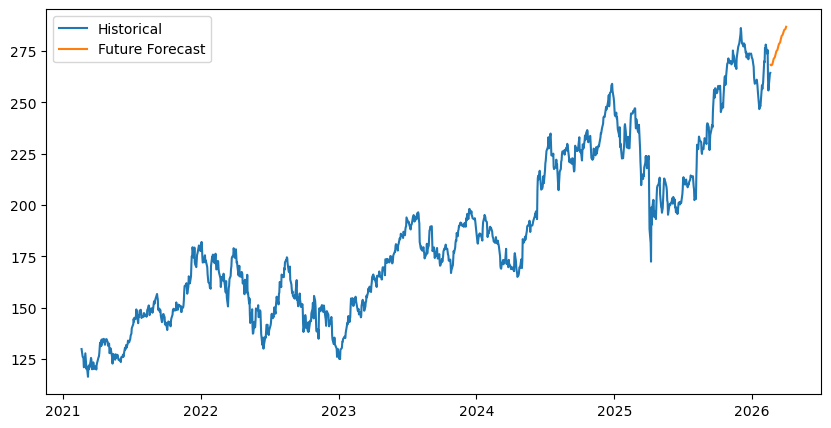

Feature : high


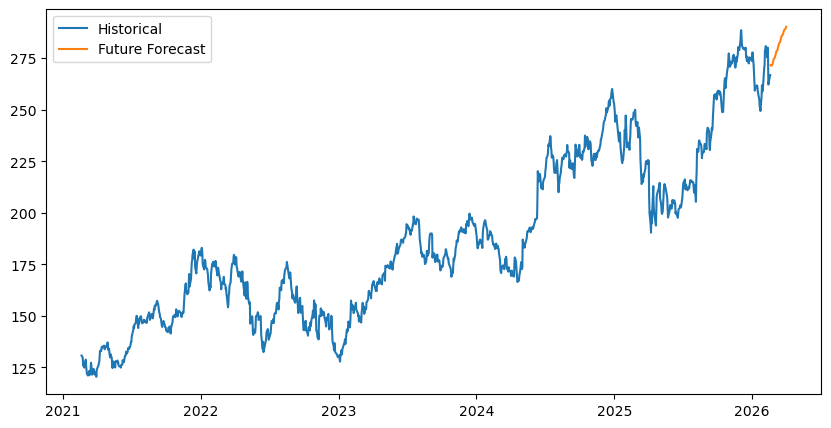

Feature : low


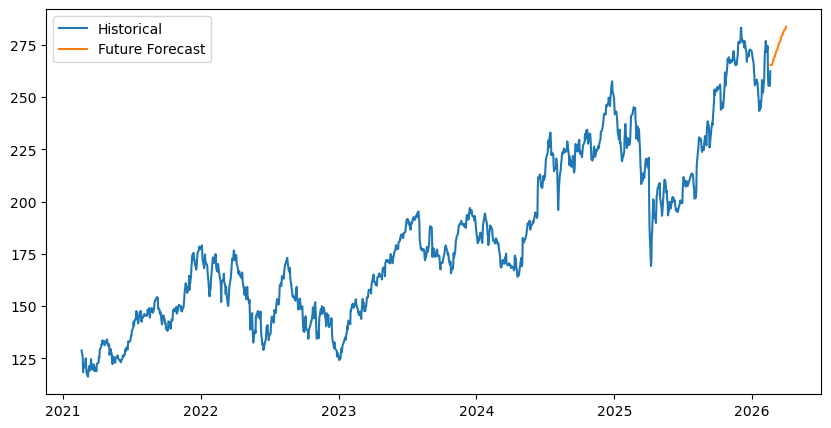

Feature : open


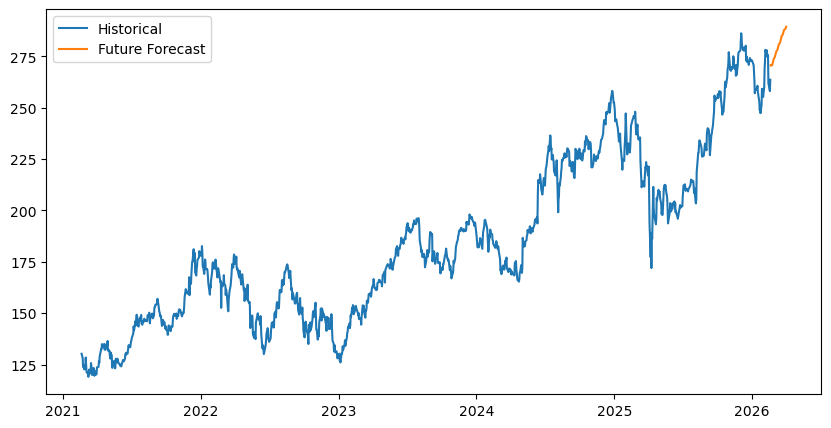

Feature : volume


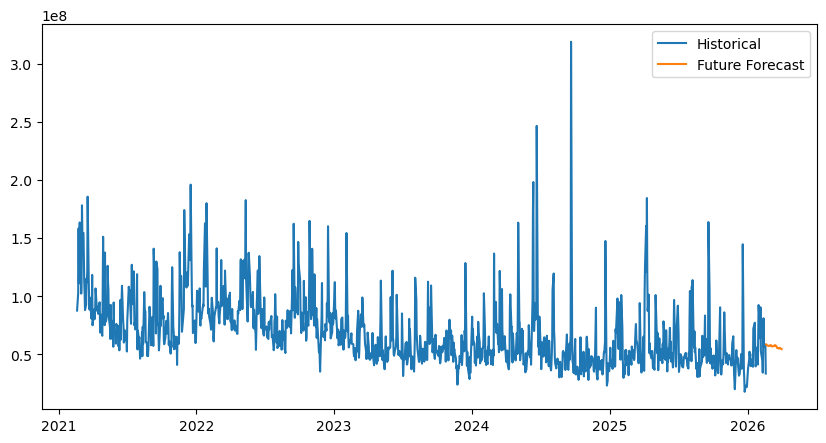

In [41]:
### generating the graphs of the model_90 predictions of next 30 days
gen_future_price_graphs(df, df_scaled, features_to_target, future_dates_30, future_prices_30_90)

In [43]:
### model_120 predictions on the next 30 days
future_prices_30_120 = gen_future_prices(30, last_sequence_30, model_120, scaler = scaler)
future_prices_30_120

array([[2.59974738e+02, 2.63688936e+02, 2.57571350e+02, 2.59957966e+02,
        4.70726403e+07],
       [2.58238895e+02, 2.61885027e+02, 2.55880383e+02, 2.58205777e+02,
        4.67308797e+07],
       [2.56455020e+02, 2.60047248e+02, 2.54135746e+02, 2.56408212e+02,
        4.64743946e+07],
       [2.54722658e+02, 2.58246978e+02, 2.52408438e+02, 2.54631034e+02,
        4.63315525e+07],
       [2.52962824e+02, 2.56431097e+02, 2.50665593e+02, 2.52846363e+02,
        4.61459427e+07],
       [2.51240829e+02, 2.54645817e+02, 2.48958184e+02, 2.51085166e+02,
        4.61008535e+07],
       [2.49543037e+02, 2.52893565e+02, 2.47305302e+02, 2.49354222e+02,
        4.61285242e+07],
       [2.47835274e+02, 2.51145252e+02, 2.45658515e+02, 2.47634137e+02,
        4.60830271e+07],
       [2.46082404e+02, 2.49385931e+02, 2.44000514e+02, 2.45926449e+02,
        4.59485480e+07],
       [2.44414787e+02, 2.47700505e+02, 2.42376335e+02, 2.44275017e+02,
        4.62303599e+07],
       [2.42858550e+02, 2.4608

Feature : close


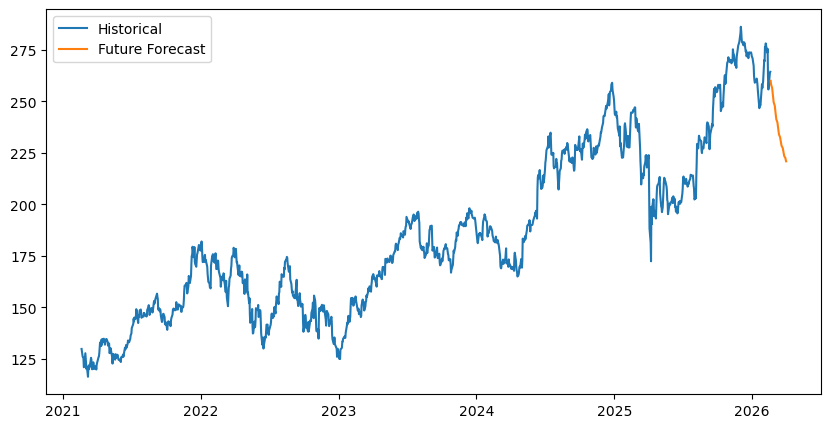

Feature : high


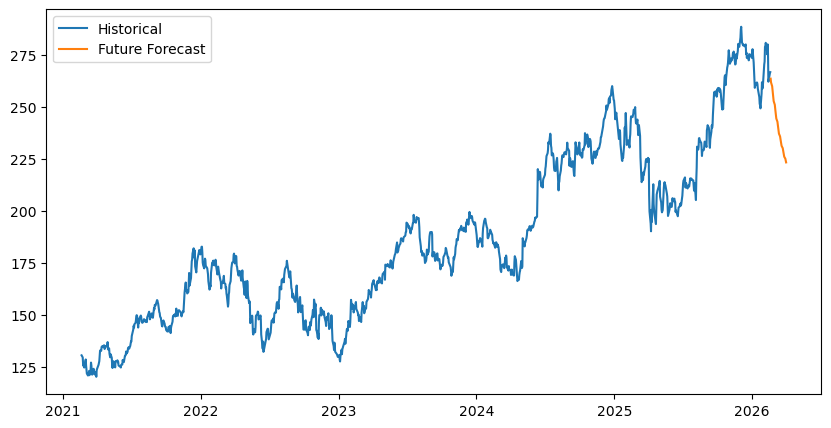

Feature : low


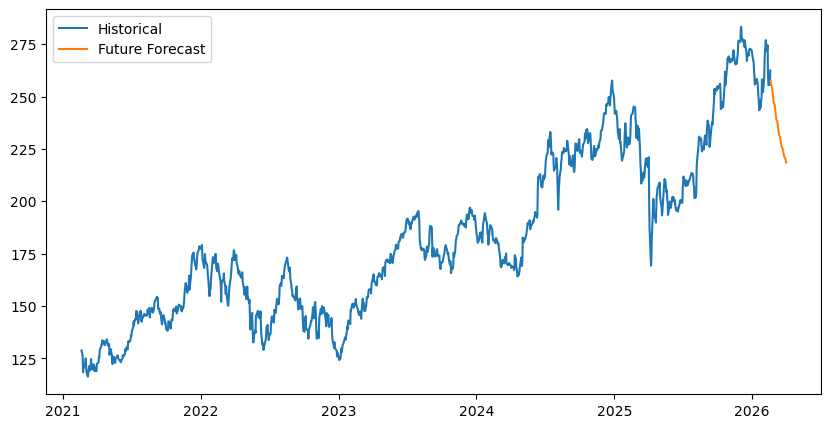

Feature : open


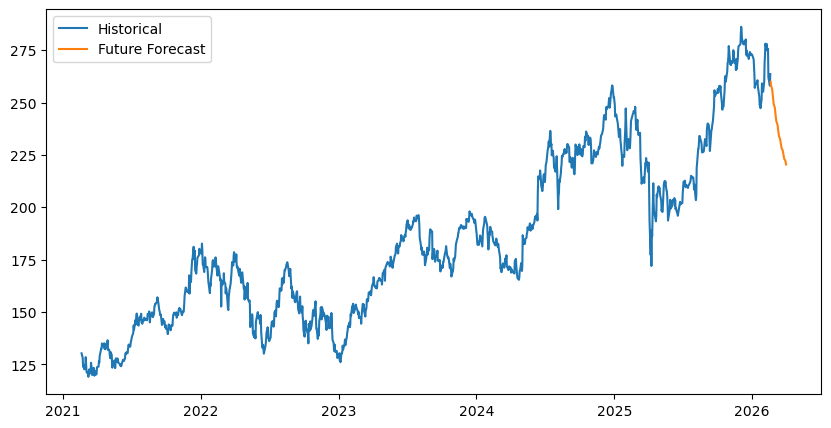

Feature : volume


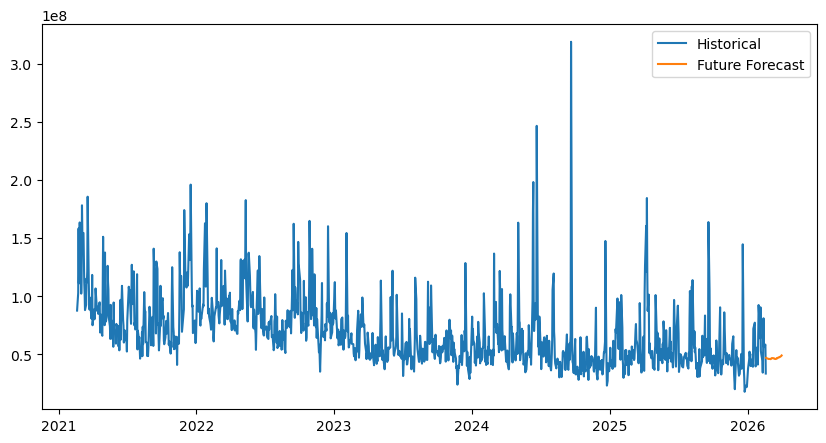

In [44]:
### generating the graphs
gen_future_price_graphs(df, df_scaled, features_to_target, future_dates_30, future_prices_30_120)

### 60 future days predictions

In [46]:
### getting the last sequence of 60 days
last_sequence_60 = df[features_to_target][-60 : ]
last_sequence_60

,close,high,low,open,volume
1195,0.882588,0.921589,0.895984,0.908058,0.092805
1196,0.913443,0.909105,0.894488,0.878866,0.136717
1197,0.939528,0.930923,0.925788,0.908476,0.158511
1198,0.945710,0.951016,0.951822,0.934617,0.096432
1199,0.949126,0.945963,0.960081,0.944727,0.051604
1200,0.956780,0.942812,0.956230,0.946522,0.007398
1201,0.981805,0.969088,0.957149,0.951008,0.095346
1202,1.000000,0.992747,0.995991,0.980858,0.118892
1203,0.987988,1.000000,1.000000,1.000000,0.085209
1204,0.967674,0.976875,0.971812,0.987408,0.086706


In [47]:
### future 60 days dates
future_dates_60 = gen_future_dates(last_date, window_size = 60)
future_dates_60

DatetimeIndex(['2026-02-19', '2026-02-20', '2026-02-23', '2026-02-24',
               '2026-02-25', '2026-02-26', '2026-02-27', '2026-03-02',
               '2026-03-03', '2026-03-04', '2026-03-05', '2026-03-06',
               '2026-03-09', '2026-03-10', '2026-03-11', '2026-03-12',
               '2026-03-13', '2026-03-16', '2026-03-17', '2026-03-18',
               '2026-03-19', '2026-03-20', '2026-03-23', '2026-03-24',
               '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30',
               '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-03',
               '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09',
               '2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15',
               '2026-04-16', '2026-04-17', '2026-04-20', '2026-04-21',
               '2026-04-22', '2026-04-23', '2026-04-24', '2026-04-27',
               '2026-04-28', '2026-04-29', '2026-04-30', '2026-05-01',
               '2026-05-04', '2026-05-05', '2026-05-06', '2026-05-07',
      

In [49]:
### model_90 predictions on the future 60 days
future_prices_60_90 = gen_future_prices(60, last_sequence_60, model_90, scaler = scaler)
future_prices_60_90

array([[2.68429201e+02, 2.72035082e+02, 2.65547297e+02, 2.70715726e+02,
        5.86304492e+07],
       [2.68313742e+02, 2.71964255e+02, 2.65537019e+02, 2.70535365e+02,
        5.82546627e+07],
       [2.68827133e+02, 2.72446229e+02, 2.66055980e+02, 2.71055641e+02,
        5.77110458e+07],
       [2.69648506e+02, 2.73182516e+02, 2.66861412e+02, 2.71902830e+02,
        5.69314167e+07],
       [2.70592292e+02, 2.74089654e+02, 2.67819580e+02, 2.72865741e+02,
        5.64954618e+07],
       [2.71591621e+02, 2.75089247e+02, 2.68843619e+02, 2.73885328e+02,
        5.63216079e+07],
       [2.72592782e+02, 2.76147013e+02, 2.69869770e+02, 2.74898280e+02,
        5.65617613e+07],
       [2.73647026e+02, 2.77168614e+02, 2.70882595e+02, 2.75966283e+02,
        5.63170723e+07],
       [2.74658725e+02, 2.78119308e+02, 2.71830744e+02, 2.77022887e+02,
        5.58664843e+07],
       [2.75584391e+02, 2.79031048e+02, 2.72746047e+02, 2.77965442e+02,
        5.56129348e+07],
       [2.76476865e+02, 2.7991

Feature : close


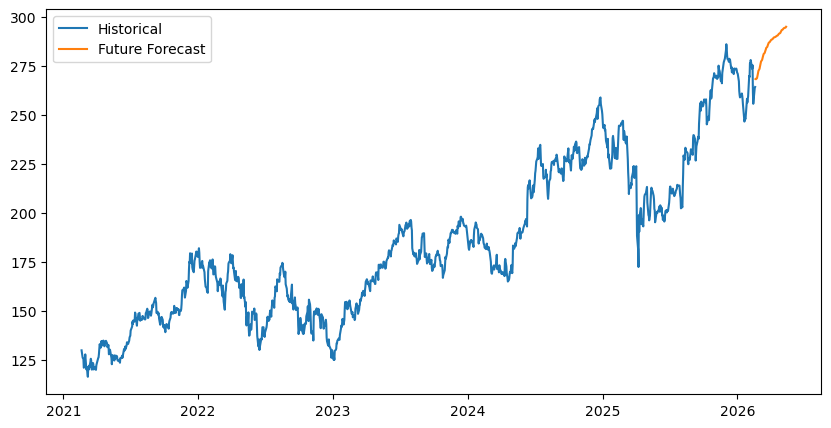

Feature : high


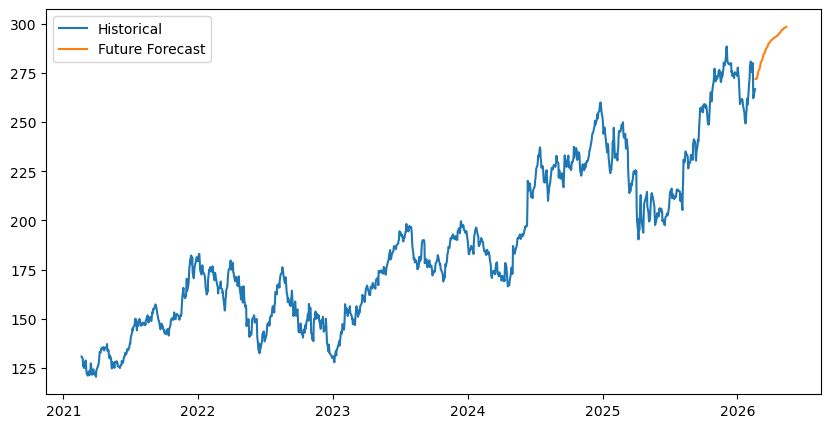

Feature : low


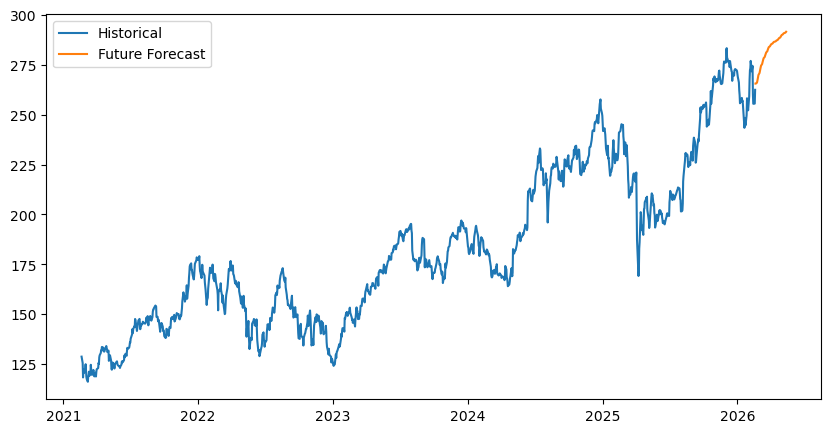

Feature : open


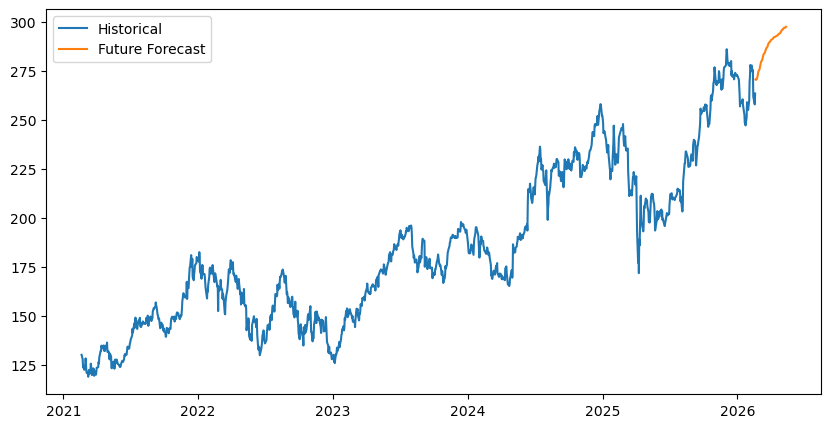

Feature : volume


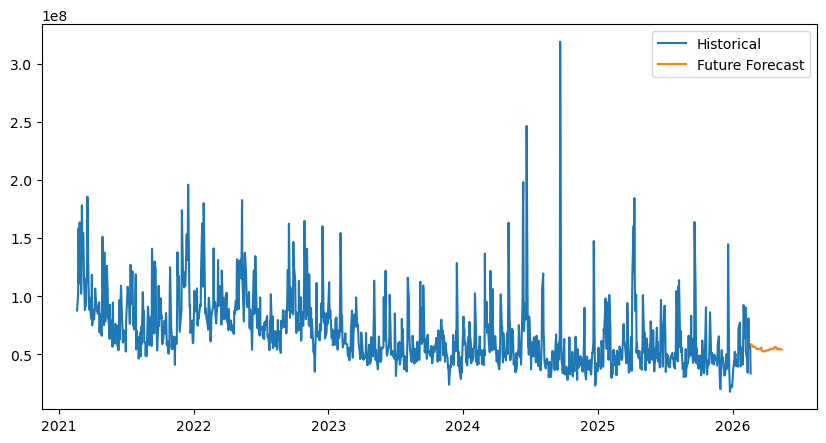

In [50]:
### making the graphs
gen_future_price_graphs(df, df_scaled, features_to_target, future_dates_60, future_prices_60_90)

Feature : close


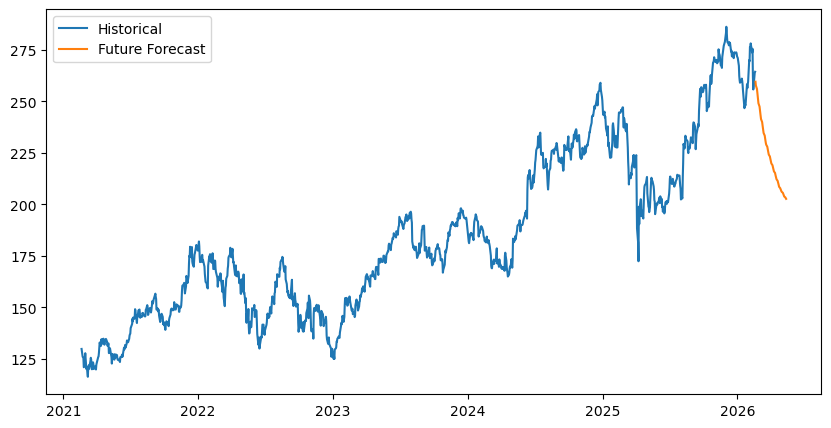

Feature : high


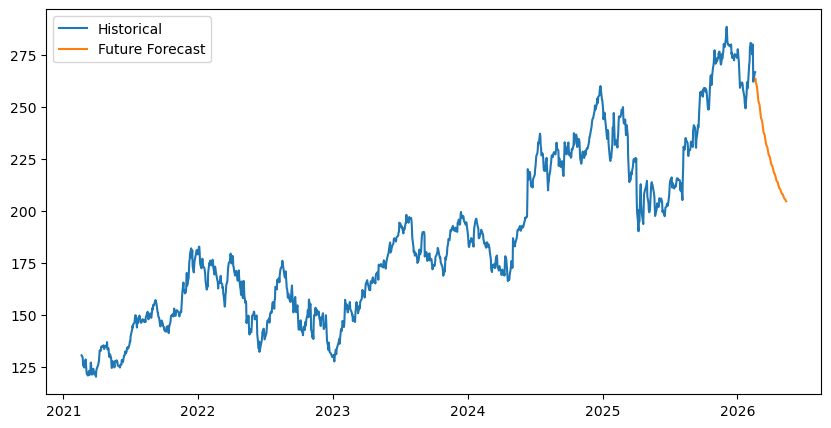

Feature : low


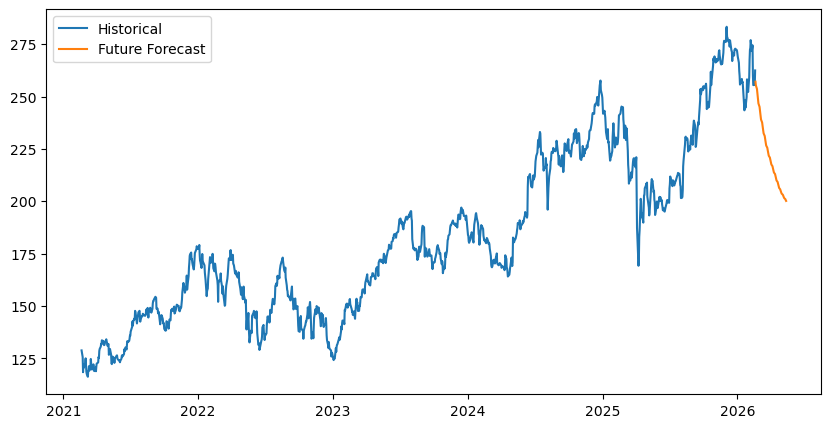

Feature : open


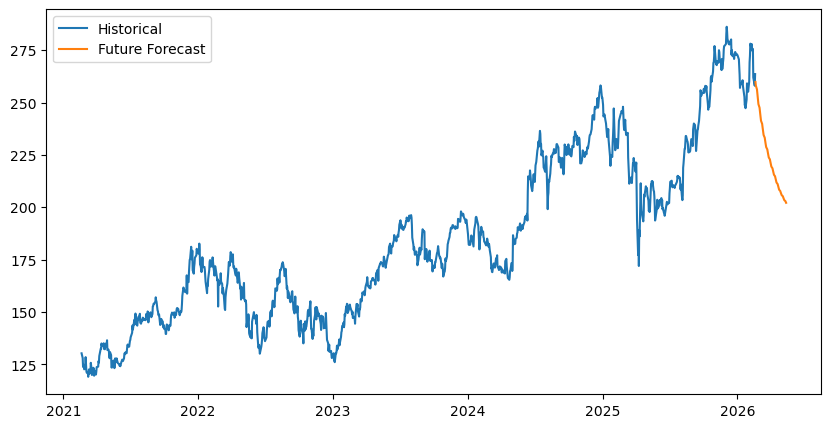

Feature : volume


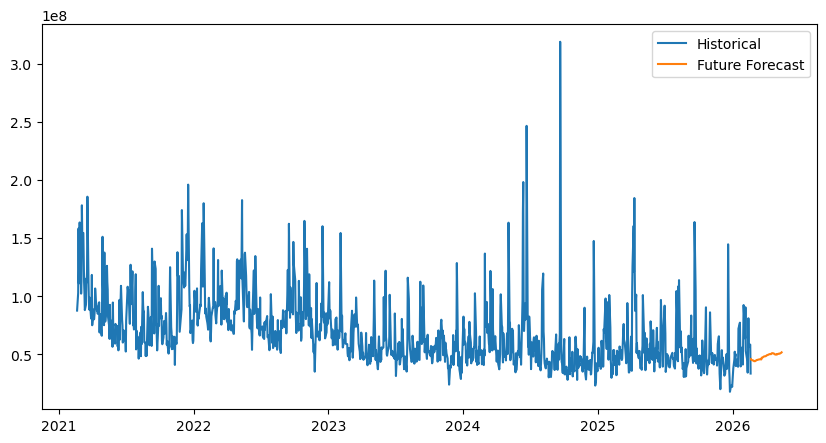

In [51]:
### model_120 predictions on the next 60 days and graphs
future_prices_60_120 = gen_future_prices(60, last_sequence_60, model_120, scaler = scaler)
gen_future_price_graphs(df, df_scaled, features_to_target, future_dates_60, future_prices_60_120)

### 90 days window

In [52]:
### getting the last sequence of 90 days and the future dates as well
last_sequence_90 = df[features_to_target][-90 : ]
future_dates_90 = gen_future_dates(last_date, window_size = 90)

Feature : close


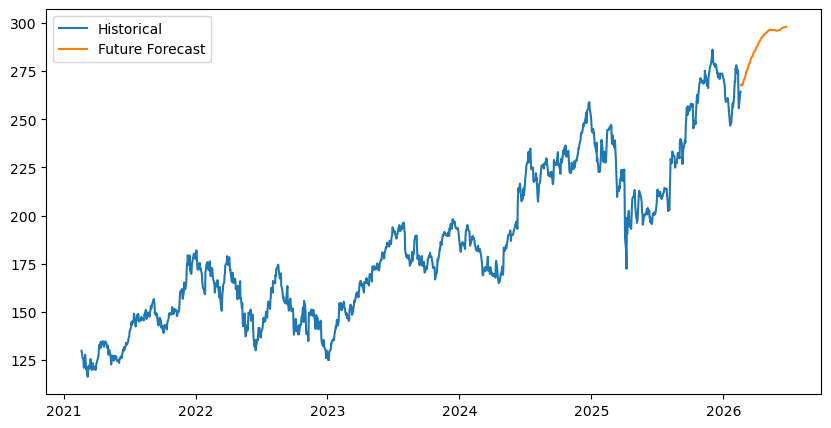

Feature : high


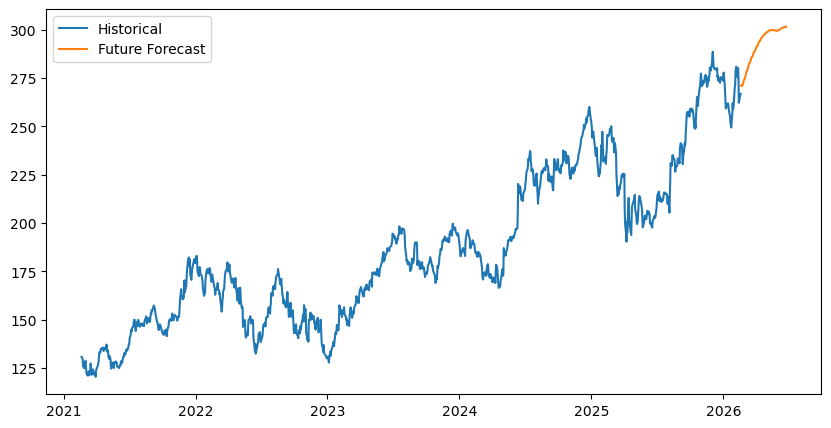

Feature : low


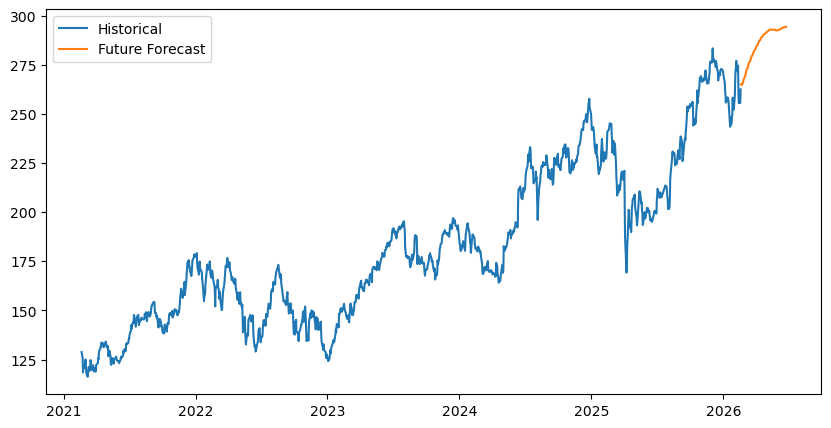

Feature : open


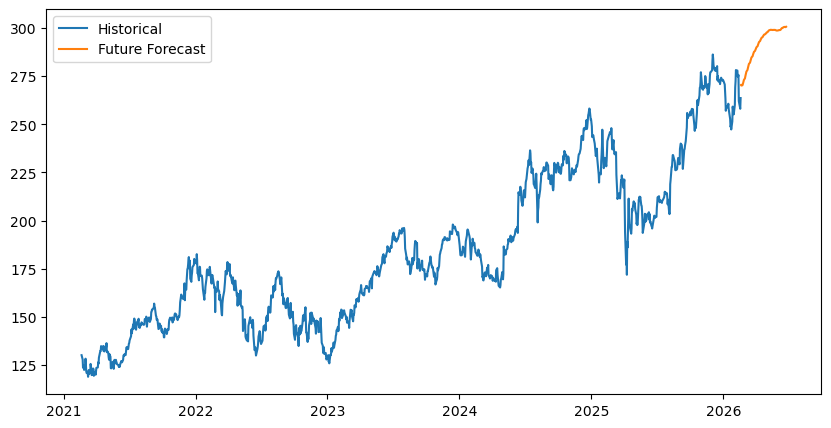

Feature : volume


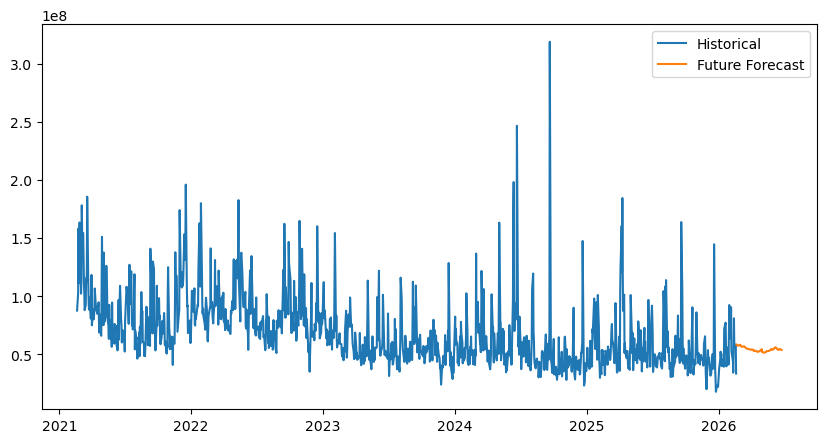

In [ ]:
### model_90 predictions on the next 90 days and graphs
future_prices_90_90 = gen_future_prices(90, last_sequence_90, model_90, scaler = scaler)
gen_future_price_graphs(df, df_scaled, features_to_target, future_dates_90, future_prices_90_90)

Feature : close


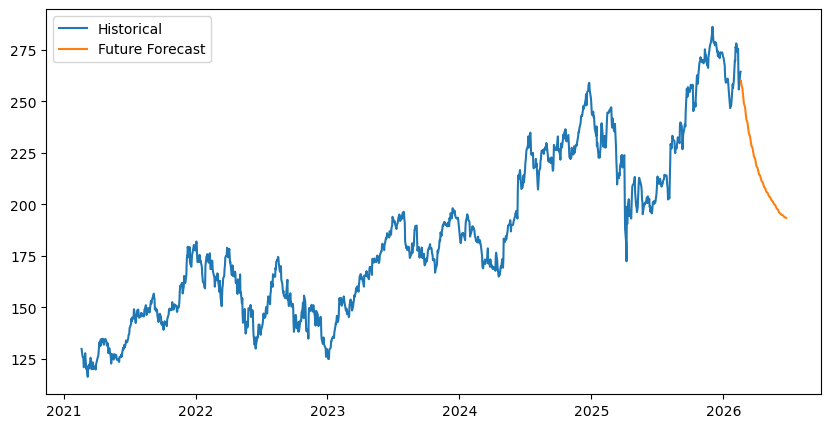

Feature : high


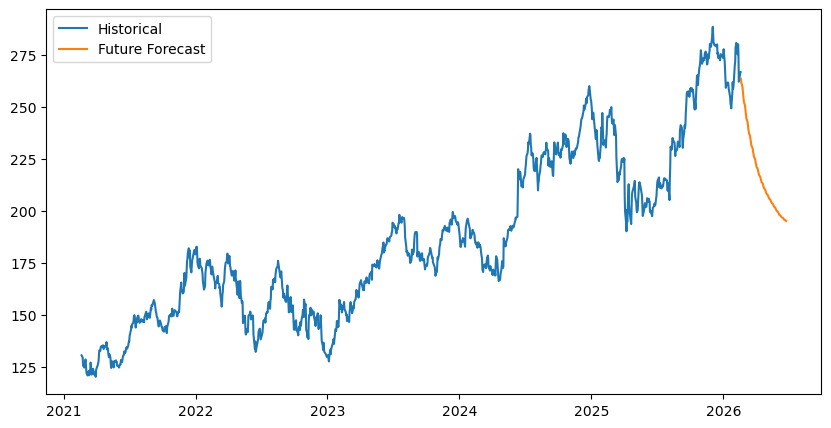

Feature : low


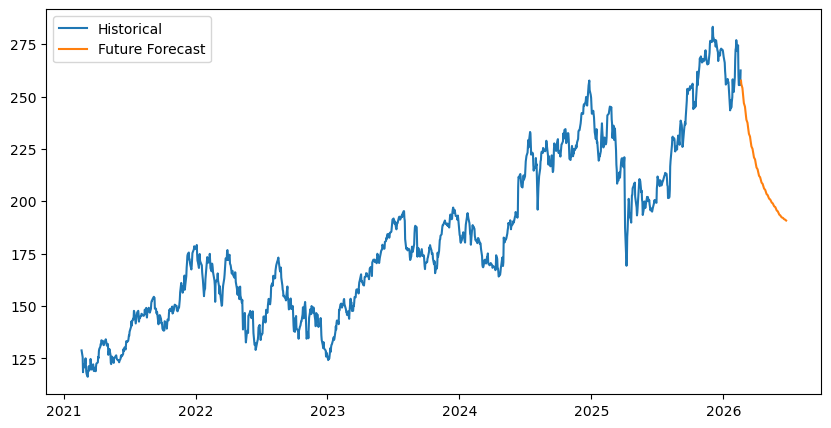

Feature : open


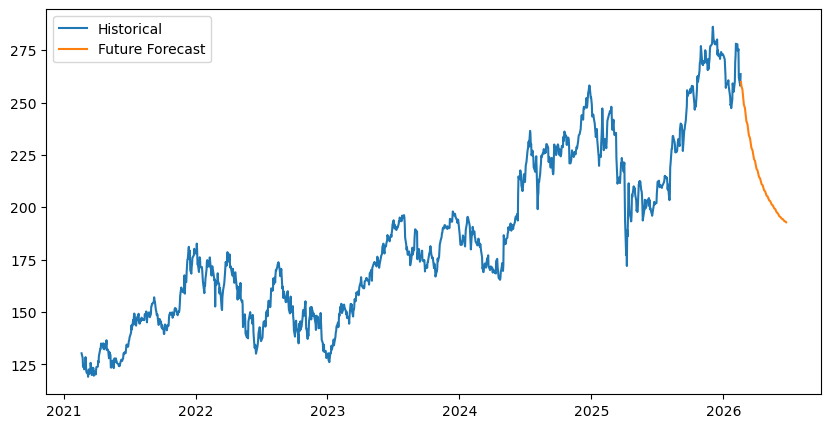

Feature : volume


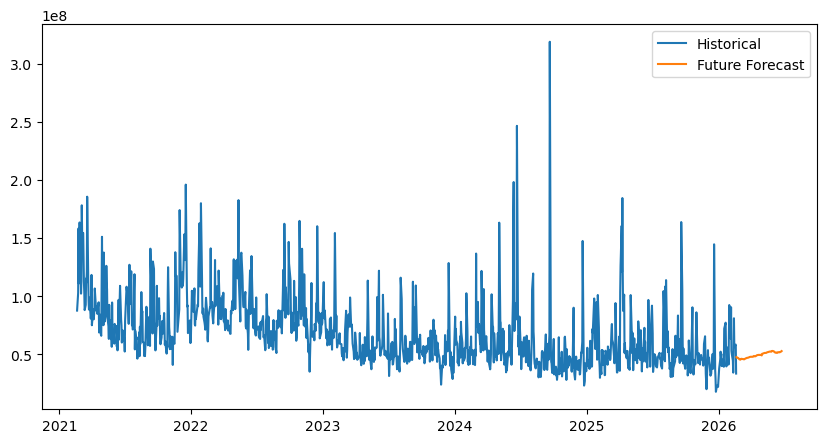

In [54]:
### model_120 predictions on the next 90 days and graphs
future_prices_90_120 = gen_future_prices(90, last_sequence_90, model_120, scaler = scaler)
gen_future_price_graphs(df, df_scaled, features_to_target, future_dates_90, future_prices_90_120)

### 120 days window

In [55]:
### getting the last sequence of 120 days and the future dates as well
last_sequence_120 = df[features_to_target][-120 : ]
future_dates_120 = gen_future_dates(last_date, window_size = 120)

Feature : close


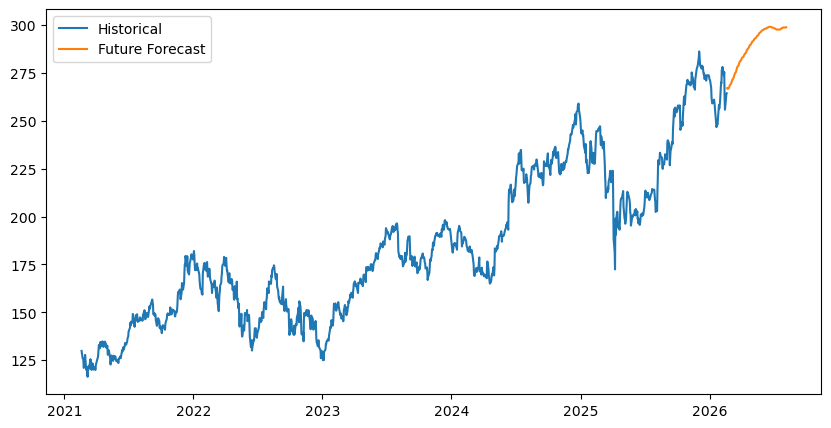

Feature : high


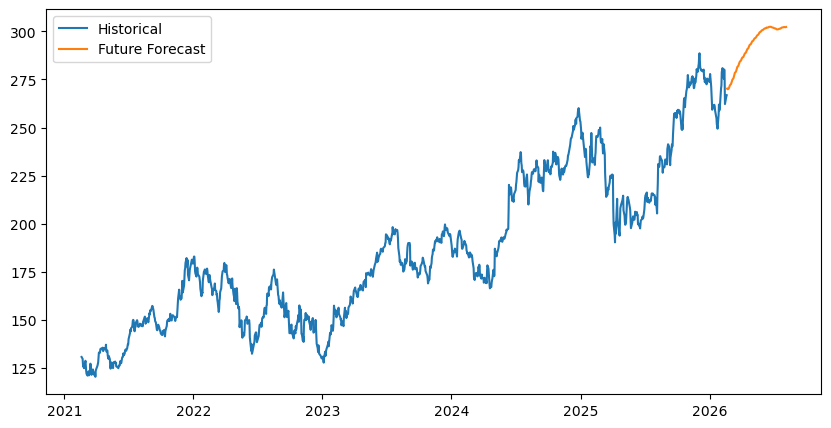

Feature : low


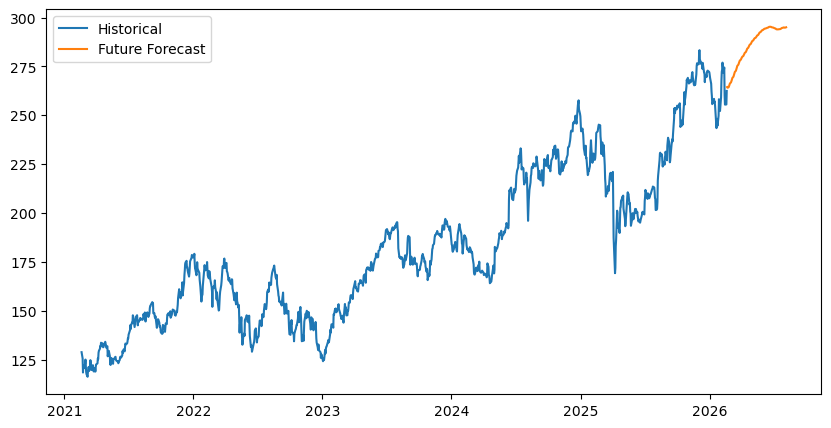

Feature : open


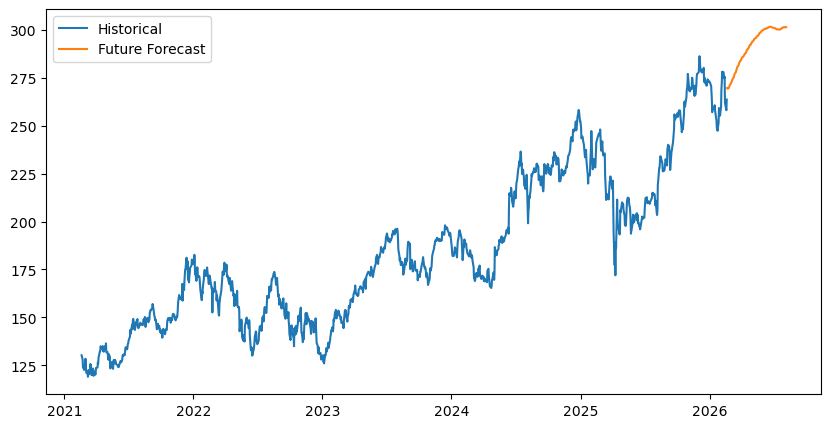

Feature : volume


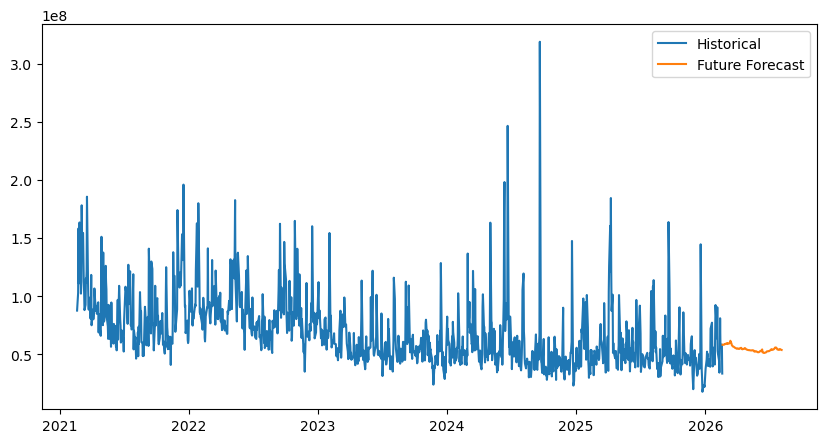

In [57]:
### model_90 predictions on the next 120 days and graphs
future_prices_120_90 = gen_future_prices(120, last_sequence_120, model_90, scaler = scaler)
gen_future_price_graphs(df, df_scaled, features_to_target, future_dates_120, future_prices_120_90)

Feature : close


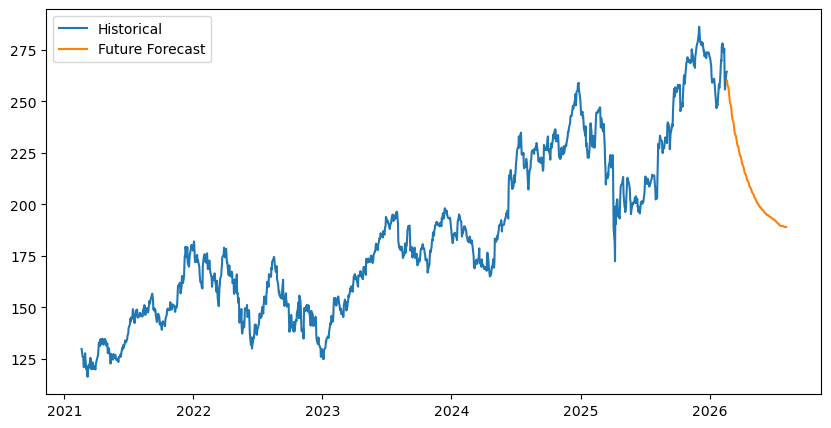

Feature : high


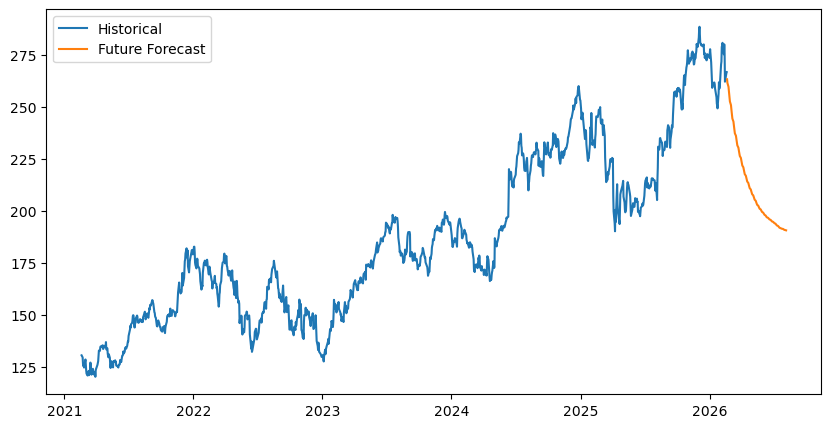

Feature : low


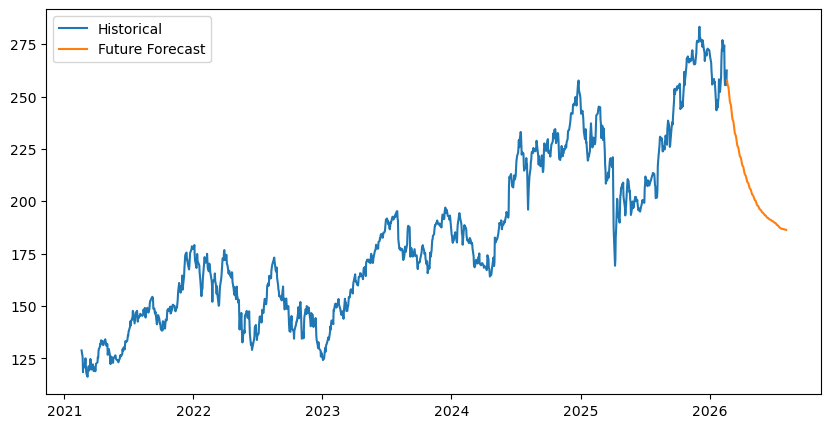

Feature : open


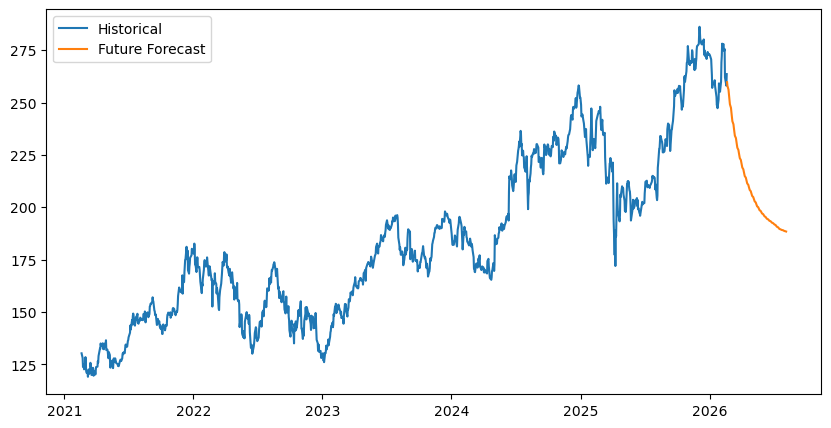

Feature : volume


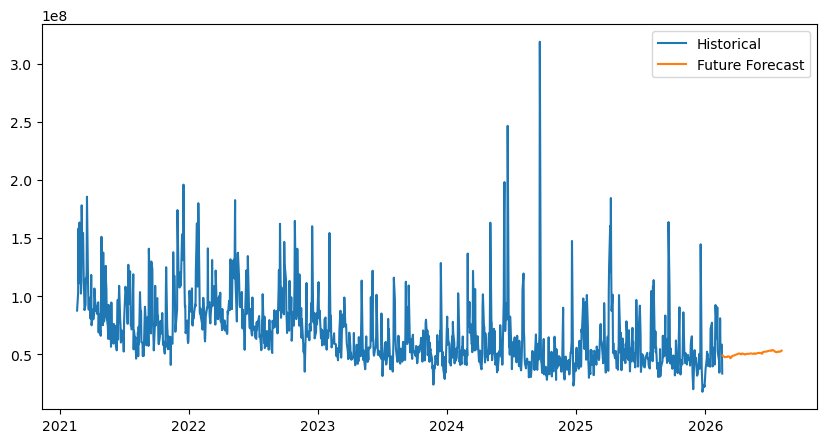

In [58]:
### model_120 predictions on the next 120 days and graphs
future_prices_120_120 = gen_future_prices(120, last_sequence_120, model_120, scaler = scaler)
gen_future_price_graphs(df, df_scaled, features_to_target, future_dates_120, future_prices_120_120)